# Fluxes L0 checks IRGA72 (2016-2025)

In [1]:
import diive as dv
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
from diive.core.io.files import load_parquet

In [2]:
# The merged Level-0 record written by 01_IRGA72-L0_merge_output_to_parquet_2016-2025. It lives in
# the external (untracked) data folder and is addressed by absolute path, so this notebook does not
# depend on the working directory.
SOURCEPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
              r"\workflow\00_L0_checks\IRGA72"
              r"\01_OPENLAG_EDDYPRO_FLUXNET_OUTPUT_IRGA72_2016-2025.parquet")
df = load_parquet(filepath=SOURCEPATH)
df

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\00_L0_checks\IRGA
72\01_OPENLAG_EDDYPRO_FLUXNET_OUTPUT_IRGA72_2016-2025.parquet (2.826 seconds).

,AIR_MV,AIR_DENSITY,AIR_RHO_CP,AIR_CP,AOA_METHOD,AXES_ROTATION_METHOD,BOWEN,BURBA_METHOD,BADM_LOCATION_LAT,BADM_LOCATION_LONG,BADM_LOCATION_ELEV,BADM_HEIGHTC,BADM_INST_SAMPLING_INT,BADM_INST_AVERAGING_INT,BADM_INST_MODEL_SA,...,W_T_SONIC_COV_IBROM_N0004,W_NUM_SPIKES,WD_FILTER_NREX,W_SPIKE_NREX,W_ABSLIM_NREX,W_VM97_TEST,W_LGD,W_KID,W_ZCD,W_ITC,W_ITC_TEST,WBOOST_APPLIED,WPL_APPLIED,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 15:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 15:45:00,0.025415,1.13966,1145.77,1005.36,0.0,1.0,NaN,0.0,47.4783,8.36439,689.0,37.0,20.0,30.0,NaN,...,NaN,1.0,0.0,1.0,0.0,801010000.0,1.50,7.65689,0.0,4.0,1.0,0.0,0.0,0.009173,0.009198
2016-01-11 16:15:00,0.025509,1.13546,1141.57,1005.38,0.0,1.0,NaN,0.0,47.4783,8.36439,689.0,37.0,20.0,30.0,NaN,...,NaN,0.0,0.0,0.0,0.0,801010000.0,1.55,7.31186,0.0,6.0,1.0,0.0,0.0,0.008916,0.008932
2016-01-11 16:45:00,0.025582,1.13222,1138.33,1005.40,0.0,1.0,NaN,0.0,47.4783,8.36439,689.0,37.0,20.0,30.0,NaN,...,NaN,0.0,0.0,0.0,0.0,800010000.0,0.10,8.96945,1.0,7.0,1.0,0.0,0.0,-0.024976,-0.025218
2016-01-11 17:15:00,0.025625,1.13030,1136.42,1005.41,0.0,1.0,NaN,0.0,47.4783,8.36439,689.0,37.0,20.0,30.0,NaN,...,NaN,1.0,0.0,2.0,0.0,800010000.0,0.80,7.41958,0.0,9.0,1.0,0.0,0.0,-0.000850,-0.000857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 22:45:00,0.024009,1.20514,1213.13,1006.63,0.0,1.0,0.067569,0.0,47.4783,8.36439,689.0,37.0,20.0,30.0,NaN,...,NaN,0.0,0.0,0.0,0.0,800000011.0,0.00,11.29880,4601.0,49.0,3.0,0.0,0.0,-0.015730,-0.030361
2025-12-31 23:15:00,0.024015,1.20467,1212.83,1006.78,0.0,1.0,4.971290,0.0,47.4783,8.36439,689.0,37.0,20.0,30.0,NaN,...,NaN,18.0,0.0,32.0,0.0,800000011.0,0.00,19.45800,7892.0,32.0,3.0,0.0,0.0,0.686305,0.697002
2025-12-31 23:45:00,0.024015,1.20467,1212.86,1006.79,0.0,1.0,1.369620,0.0,47.4783,8.36439,689.0,37.0,20.0,30.0,NaN,...,NaN,1.0,0.0,2.0,0.0,800000011.0,0.00,13.98160,6271.0,20.0,2.0,0.0,0.0,2.106530,2.193120


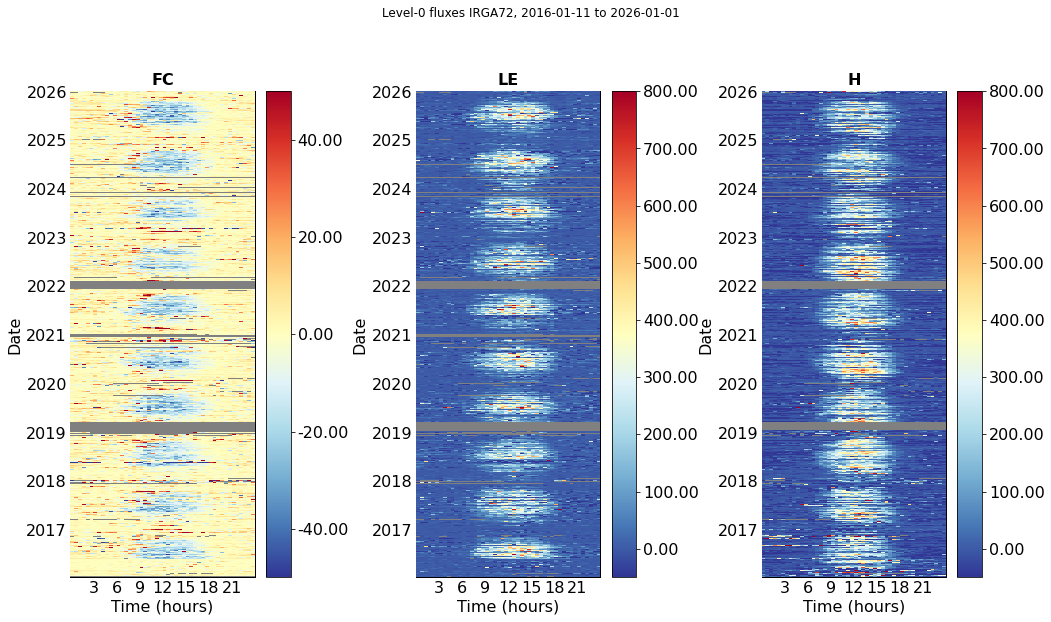

In [3]:
fig = plt.figure(figsize=(16, 9), dpi=72)
fig.suptitle(f"Level-0 fluxes IRGA72, {df.index[0].date()} to {df.index[-1].date()}")
gs = gridspec.GridSpec(1, 3)  # rows, cols
gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
ax_fc = fig.add_subplot(gs[0, 0])
ax_le = fig.add_subplot(gs[0, 1])
ax_h = fig.add_subplot(gs[0, 2])

# Heatmaps are built in two phases in current diive: the class prepares the series, plot() styles
# it. The title travels in a FormatStyle rather than as a keyword.
for _ax, _col, _vmin, _vmax in [(ax_fc, 'FC', -50, 50), (ax_le, 'LE', -50, 800), (ax_h, 'H', -50, 800)]:
    dv.plotting.HeatmapDateTime(series=df[_col]).plot(
        ax=_ax, vmin=_vmin, vmax=_vmax, format_style=dv.plotting.FormatStyle(title=_col))

# End of notebook.

In [4]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-07-31 13:00:35
